In [1]:
# --- preparação do ambiente (rode esta célula primeiro) ---
# Acha a raiz do projeto; se não existir, estamos no Colab e o repositório é clonado.
import os
import pathlib
import subprocess

REPOSITORIO = "https://github.com/thxggz/dr1-at-algoritmos.git"
DESTINO_CLONE = pathlib.Path("/content/dr1-at-algoritmos")


def raiz_do_projeto() -> pathlib.Path | None:
    """Primeiro diretório, subindo a partir do atual, que contenha src/counters.py."""
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (base / "src" / "counters.py").exists():
            return base
    return None


raiz = raiz_do_projeto()
if raiz is None:
    if not DESTINO_CLONE.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORIO, str(DESTINO_CLONE)],
            check=True,
        )
    raiz = DESTINO_CLONE
os.chdir(raiz)
print(f"raiz do projeto: {raiz}")
print("o código vive em src/; este notebook importa e demonstra")

raiz do projeto: C:\Users\kikea\dr1-at-aed
o código vive em src/; este notebook importa e demonstra


# Exercício 12 — Motor de indexação e consulta (integrador)

**Henrique Goldstein Maluhy Mendes Amaral** · Infnet · DR1_AT — Algoritmos e Estruturas de Dados

Este notebook cobre **um** exercício. O código está em `src/`, testado por `pytest`; aqui ele é importado e demonstrado. A primeira célula prepara o ambiente — rode-a antes das outras, ou use **Ambiente de execução → Executar tudo**.

**Os doze exercícios:**

1. [Exercício 1](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex01_buscas.ipynb)
2. [Exercício 2](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex02_ordenacoes_quadraticas.ipynb)
3. [Exercício 3](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex03_otimizacao.ipynb)
4. [Exercício 4](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex04_hashtable.ipynb)
5. [Exercício 5](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex05_pilha_fila_expressao.ipynb)
6. [Exercício 6](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex06_simulador_de_filas.ipynb)
7. [Exercício 7](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex07_recursao_diretorios.ipynb)
8. [Exercício 8](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex08_programacao_dinamica.ipynb)
9. [Exercício 9](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex09_quicksort_quickselect.ipynb)
10. [Exercício 10](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex10_lista_encadeada.ipynb)
11. [Exercício 11](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex11_lista_dupla_deque.ipynb)
12. Exercício 12 **→ você está aqui**

---


---
# Seção 0 — Instrumentação compartilhada

Antes dos exercícios, a peça de que todos dependem.

Existe **um único** contador, definido em `src/counters.py` e reutilizado pelos
12 exercícios. Sem isso, "o insertion sort faz 4.193 comparações" e "a BST faz
1.904.423" não seriam números comparáveis.

```python
@dataclass
class Counters:
    comparisons: int = 0   # comparações de chaves
    copies: int = 0        # movimentações (1 troca = 3 cópias)
    calls: int = 0         # chamadas recursivas
    hops: int = 0          # saltos de ponteiro em estrutura encadeada
```

**Os três primeiros são exigência do enunciado.** O quarto, `hops`, foi
acrescentado — e a razão é o exercício 10: com ponteiro `tail`, `insert_last`
faz 0 comparações e 1 cópia, *exatamente como* a versão sem `tail`. Os
contadores obrigatórios são cegos para a diferença entre O(1) e O(n) ali. Sem
`hops`, a evidência quantitativa que a rubrica cobra não existiria.

**Critérios fixos, válidos no trabalho inteiro:**

- uma **troca** conta 3 cópias (`tmp = a; a = b; b = tmp`); um **deslocamento**
  conta 1;
- uma **sondagem** de busca (linear, binária ou descida em BST) conta **uma**
  comparação de três vias, não duas;
- toda função instrumentada aceita um `Counters` do chamador e tem um irmão
  `*_counted` que devolve `(resultado, Counters)`.

In [2]:
from __future__ import annotations

import math
import pathlib
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebook" else pathlib.Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
FIGURAS = RAIZ / "figures"
FIGURAS.mkdir(exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)

from src.counters import COPIES_PER_SWAP, RANDOM_SEED, Counters

print(f"semente dos experimentos: {RANDOM_SEED}")
print(f"uma troca conta {COPIES_PER_SWAP} cópias")
print(f"campos do contador: {list(Counters().as_dict())}")

semente dos experimentos: 42
uma troca conta 3 cópias
campos do contador: ['comparisons', 'copies', 'calls', 'hops']


In [3]:
def mostrar(df: pd.DataFrame, colunas: list[str] | None = None, titulo: str = "") -> pd.DataFrame:
    """Exibe a tabela de medições, opcionalmente só com as colunas pedidas."""
    if titulo:
        print(titulo)
    return df[colunas] if colunas else df


def grafico_loglog(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Gráfico log-log — usado sempre que há 4 ou mais pontos por curva."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def grafico_razao(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Razão contra a curva teórica: reta horizontal = a classe está certa."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def veredito(texto: str) -> None:
    """Conclusão calculada a partir da tabela imediatamente acima."""
    print("\n" + "=" * 78)
    print(texto)
    print("=" * 78)

In [4]:
# Estruturas definidas na seção de outro exercício do notebook
# único, reimportadas aqui para este notebook rodar sozinho.
from src.bst import BinarySearchTree
from src.linked_list import SinglyLinkedList

---
# Exercício 12 — Motor de indexação e consulta (integrador)

## Enunciado
Índice invertido em `HashTableChained` com listas encadeadas de ocorrências e BST
de termos; consultas booleanas com parênteses e AND/OR/NOT por shunting-yard com
`Stack`; `Queue` para BFS na BST gerando relatório de diagnóstico; ranqueamento
por frequência e posição ordenado com o quicksort do ex 9; sugestão de termo por
distância de edição com memoization; e **duas otimizações** justificadas em Big O
e com evidência.

## Implementação — `src/search_engine.py`

As **oito** estruturas exigidas, e onde cada uma entra:

| Estrutura | Papel aqui |
|---|---|
| `HashTableChained` (ex 4) | índice invertido termo → ocorrências; memo da DP |
| `SinglyLinkedList` (ex 10) | lista de ocorrências de cada termo |
| `BinarySearchTree` (ex 2) | árvore de termos, listagem ordenada e busca |
| `Stack` (ex 5) | shunting-yard e avaliação da consulta |
| `Queue` (ex 5) | percurso em largura da BST (relatório) |
| `quicksort` (ex 9) | ranqueamento dos documentos |
| recursão (ex 7) | distância de edição |
| DP com memo (ex 8) | distância de edição memoizada |

**Decisão de projeto 1 — as listas de ocorrências nascem ordenadas por `doc_id`,
de graça.** Os documentos são indexados em ordem crescente e cada ocorrência é
anexada ao fim com `insert_last`, que é O(1) graças ao `tail` do ex 10. Manter a
ordem não custa nada — e é o que habilita a otimização 1.

In [5]:
from src.search_engine import (InvertedIndex, SearchEngine, bench_edit_distance,
                               bench_index_lookup, bench_indexing, bench_intersection,
                               bench_suggestion, edit_distance, edit_distance_naive,
                               generate_corpus, intersect_naive, intersect_sorted,
                               performance_report, run_query, suggest_terms, to_postfix,
                               tokenize_query)

DOCUMENTOS = [
    "Algoritmos de ordenação: bubble sort, insertion sort e selection sort.",
    "Estruturas de dados: lista encadeada, pilha, fila e árvore binária.",
    "Análise de algoritmos com notação Big O e contagem de comparações.",
    "A árvore binária de busca degenera quando a entrada já está ordenada.",
    "Tabela hash com encadeamento resolve colisões usando lista encadeada.",
    "QuickSort escolhe um pivô e particiona; QuickSelect desce em um lado só.",
]
motor = SearchEngine(DOCUMENTOS)
motor.index.check_invariants()
print(motor.index)

# as estruturas exigidas estão mesmo lá
from src.hashtable import HashTableChained as _HT
assert isinstance(motor.index._postings, _HT)
assert isinstance(motor.index.terms_tree, BinarySearchTree)
assert isinstance(motor.index.postings("arvore"), SinglyLinkedList)
print("índice invertido: HashTableChained · ocorrências: SinglyLinkedList · termos: BST")

ocorrencias = motor.index.postings("sort").to_list()
print(f"\nocorrências de 'sort': {[(o.doc_id, o.positions) for o in ocorrencias]}")
print(f"termos em ordem (10 primeiros): {motor.index.terms_in_order()[:10]}")

InvertedIndex(docs=6, termos=47, tokens=64)
índice invertido: HashTableChained · ocorrências: SinglyLinkedList · termos: BST

ocorrências de 'sort': [(0, [4, 6, 9])]
termos em ordem (10 primeiros): ['a', 'algoritmos', 'analise', 'arvore', 'big', 'binaria', 'bubble', 'busca', 'colisoes', 'com']


In [6]:
print("CONSULTAS BOOLEANAS")
for consulta in ["arvore AND binaria", "pilha OR tabela", "algoritmos AND NOT ordenacao",
                 "(lista OR tabela) AND encadeada", "NOT NOT quicksort"]:
    resultado = motor.search(consulta)
    print(f"\n  {consulta!r}")
    print(f"     pós-fixa : {resultado.postfix}")
    print(f"     docs     : {resultado.doc_ids}")
    print(f"     ranking  : {[(d.doc_id, round(d.score, 2)) for d in resultado.top(3)]}")

print("\n\nENTRADAS INVÁLIDAS")
for consulta in ["", "(a AND b", "a AND b)", "AND arvore", "arvore binaria"]:
    try:
        run_query(consulta, motor.index)
    except Exception as erro:
        print(f"  {consulta!r:<20} → {type(erro).__name__}: {str(erro)[:60]}")

CONSULTAS BOOLEANAS

  'arvore AND binaria'
     pós-fixa : ['arvore', 'binaria', 'AND']
     docs     : [1, 3]
     ranking  : [(3, 2.83), (1, 2.21)]

  'pilha OR tabela'
     pós-fixa : ['pilha', 'tabela', 'OR']
     docs     : [1, 4]
     ranking  : [(4, 2.0), (1, 1.17)]

  'algoritmos AND NOT ordenacao'
     pós-fixa : ['algoritmos', 'ordenacao', 'NOT', 'AND']
     docs     : [2]
     ranking  : [(2, 1.33)]

  '(lista OR tabela) AND encadeada'
     pós-fixa : ['lista', 'tabela', 'OR', 'encadeada', 'AND']
     docs     : [1, 4]
     ranking  : [(4, 4.24), (1, 2.45)]

  'NOT NOT quicksort'
     pós-fixa : ['quicksort', 'NOT', 'NOT']
     docs     : [5]
     ranking  : [(5, 2.0)]


ENTRADAS INVÁLIDAS
  ''                   → EmptyQueryError: consulta vazia
  '(a AND b'           → UnbalancedParenthesesError: parêntese '(' sem ')' correspondente
  'a AND b)'           → UnbalancedParenthesesError: parêntese ')' sem '(' correspondente
  'AND arvore'         → MalformedQueryError: operad

In [7]:
print("RELATÓRIO DE DIAGNÓSTICO DA BST DE TERMOS (BFS com a Queue do ex 5)")
diagnostico = motor.index.bfs_report()
for chave in ("termos", "niveis", "altura", "altura_ideal", "balanceamento",
              "profundidade_minima", "folhas", "largura_maxima", "nivel_mais_largo",
              "raiz", "termos_por_nivel"):
    print(f"  {chave:<22} {diagnostico[chave]}")
print(f"  {'amostra do nível mais largo':<22} {diagnostico['amostra_nivel_mais_largo']}")

RELATÓRIO DE DIAGNÓSTICO DA BST DE TERMOS (BFS com a Queue do ex 5)
  termos                 47
  niveis                 9
  altura                 9
  altura_ideal           6
  balanceamento          1.5
  profundidade_minima    4
  folhas                 17
  largura_maxima         12
  nivel_mais_largo       5
  raiz                   ordenacao
  termos_por_nivel       [1, 2, 4, 7, 10, 12, 7, 3, 1]
  amostra do nível mais largo ['analise', 'binaria', 'busca', 'comparacoes', 'desce', 'encadeada', 'fila', 'lado']


### Otimização 1 — interseção por varredura de listas ordenadas

**Θ(m+n) contra Θ(m·n).** A versão ingênua compara cada elemento de uma lista com
todos os da outra. Esta aproveita a ordem e anda um ponteiro de cada vez. Como as
listas de ocorrências nascem ordenadas (decisão de projeto 1), a otimização não
custa preparação nenhuma.

In [8]:
intersecao = pd.DataFrame(bench_intersection([100, 400, 1_600, 3_200]))
mostrar(intersecao, ["n", "resultado", "ordenada_comparacoes", "ordenada/n",
                     "ingenua_comparacoes", "ingenua/n2", "razao",
                     "tempo_ordenada_s", "tempo_ingenua_s"],
        "OTIMIZAÇÃO 1 — interseção ordenada × par a par")

OTIMIZAÇÃO 1 — interseção ordenada × par a par


,n,resultado,ordenada_comparacoes,ordenada/n,ingenua_comparacoes,ingenua/n2,razao,tempo_ordenada_s,tempo_ingenua_s
0,100,10,366,3.6600,9406,0.9406,25.6995,0.0000,0.0006
1,400,40,1476,3.6900,151762,0.9485,102.8198,0.0002,0.0097
2,1600,160,5918,3.6987,2432817,0.9503,411.0877,0.0006,0.1565
3,3200,320,11838,3.6994,9731147,0.9503,822.0263,0.0012,0.6463


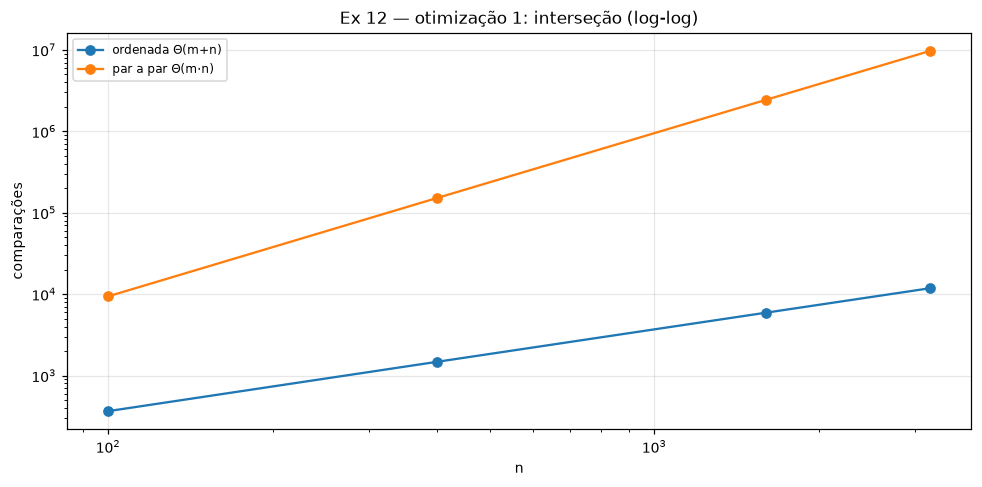


ordenada : razão contra n entre 3.6600 e 3.6994  ⇒ Θ(m+n)
par a par: razão contra n² entre 0.9406 e 0.9503  ⇒ Θ(m·n)
ganho    : 26× → 822× — cresce LINEARMENTE com n, porque é ganho de classe.

Há teste provando que as duas devolvem exatamente o mesmo resultado em 100
pares de listas sorteadas: a otimização é EXATA, só o custo muda.


In [9]:
curvas_int = pd.concat([
    intersecao.assign(versao="ordenada Θ(m+n)", comparacoes=lambda d: d["ordenada_comparacoes"]),
    intersecao.assign(versao="par a par Θ(m·n)", comparacoes=lambda d: d["ingenua_comparacoes"]),
])
grafico_loglog(curvas_int, "n", "comparacoes", "versao",
               "Ex 12 — otimização 1: interseção (log-log)",
               "ex12_otimizacao1.png", "comparações")
veredito(
    f"ordenada : razão contra n entre {intersecao['ordenada/n'].min():.4f} e "
    f"{intersecao['ordenada/n'].max():.4f}  ⇒ Θ(m+n)\n"
    f"par a par: razão contra n² entre {intersecao['ingenua/n2'].min():.4f} e "
    f"{intersecao['ingenua/n2'].max():.4f}  ⇒ Θ(m·n)\n"
    f"ganho    : {intersecao['razao'].min():.0f}× → {intersecao['razao'].max():,.0f}× — "
    "cresce LINEARMENTE com n, porque é ganho de classe.\n\n"
    "Há teste provando que as duas devolvem exatamente o mesmo resultado em 100\n"
    "pares de listas sorteadas: a otimização é EXATA, só o custo muda."
)

### Otimização 2 — poda por diferença de comprimento na sugestão

A distância de edição entre duas palavras é **pelo menos** a diferença de
comprimento delas, porque cada operação muda o tamanho em no máximo 1. Então um
candidato cujo comprimento difere do termo buscado em mais de `max_distance` pode
ser descartado **sem calcular nada** — troca-se um Θ(L²) por uma comparação O(1).

Sem a poda o custo é Θ(V·L²); com ela, Θ(V + C·L²), onde `C` é o número de
candidatos que sobrevivem ao filtro.

In [10]:
poda = pd.DataFrame(bench_suggestion())
mostrar(poda, ["vocabulario", "termo_ausente", "sugestoes", "chamadas_com_poda",
               "chamadas_sem_poda", "reducao_de_chamadas", "comparacoes_com_poda",
               "comparacoes_sem_poda", "razao_tempo"],
        "OTIMIZAÇÃO 2 — poda por comprimento")
veredito(
    f"redução de chamadas: {poda['reducao_de_chamadas'].min():.2f}× a "
    f"{poda['reducao_de_chamadas'].max():.2f}×  ·  "
    f"tempo: {poda['razao_tempo'].min():.2f}× a {poda['razao_tempo'].max():.2f}×\n"
    "E a poda é EXATA: há teste provando que as duas versões devolvem a MESMA\n"
    "lista de sugestões para cinco termos diferentes. Ela não descarta candidato\n"
    "válido — descarta candidato que a matemática garante estar fora."
)

OTIMIZAÇÃO 2 — poda por comprimento

redução de chamadas: 2.01× a 2.11×  ·  tempo: 2.07× a 2.52×
E a poda é EXATA: há teste provando que as duas versões devolvem a MESMA
lista de sugestões para cinco termos diferentes. Ela não descarta candidato
válido — descarta candidato que a matemática garante estar fora.


In [11]:
edicao = pd.DataFrame(bench_edit_distance())
mostrar(edicao, ["padrao", "distancia", "estados_possiveis", "chamadas_com_memo",
                 "chamadas_sem_memo", "memo/estados", "reducao_de_chamadas"],
        "A DP DENTRO DO EX 12 — distância de edição com e sem memo")
veredito(
    f"Mesma mudança de classe do ex 8, agora num módulo aplicado:\n"
    f"  Θ(3^L) → Θ(|a|·|b|), com redução de até "
    f"{edicao['reducao_de_chamadas'].max():,.0f}× nas chamadas.\n"
    "  A coluna memo/estados fica perto de 1: as chamadas da versão memoizada\n"
    "  ficam na ordem do tamanho do espaço de estados, que é |a|·|b|."
)

A DP DENTRO DO EX 12 — distância de edição com e sem memo

Mesma mudança de classe do ex 8, agora num módulo aplicado:
  Θ(3^L) → Θ(|a|·|b|), com redução de até 28,531× nas chamadas.
  A coluna memo/estados fica perto de 1: as chamadas da versão memoizada
  ficam na ordem do tamanho do espaço de estados, que é |a|·|b|.


In [12]:
lookup = pd.DataFrame(bench_index_lookup())
mostrar(lookup, ["vocabulario", "altura_bst", "hash_comparacoes_por_busca",
                 "bst_comparacoes_por_busca", "bst/hash", "bst_por_busca/log2V",
                 "listagem_ordenada_ok"],
        "HASHTABLE × BST PARA A MESMA PERGUNTA")
veredito(
    f"hashtable: {lookup['hash_comparacoes_por_busca'].min():.2f} a "
    f"{lookup['hash_comparacoes_por_busca'].max():.2f} comparações/busca — CONSTANTE, O(1+α)\n"
    f"BST      : {lookup['bst_comparacoes_por_busca'].min():.2f} a "
    f"{lookup['bst_comparacoes_por_busca'].max():.2f} comparações/busca — cresce com log₂V "
    f"(razão contra log₂V entre {lookup['bst_por_busca/log2V'].min():.2f} e "
    f"{lookup['bst_por_busca/log2V'].max():.2f})\n\n"
    "O experimento não elege vencedor: as duas pagam preços diferentes pelo mesmo\n"
    "resultado. A BST é mantida pelo que a hashtable NÃO faz — listar em ordem."
)

HASHTABLE × BST PARA A MESMA PERGUNTA

hashtable: 1.17 a 1.27 comparações/busca — CONSTANTE, O(1+α)
BST      : 9.31 a 13.64 comparações/busca — cresce com log₂V (razão contra log₂V entre 1.22 e 1.33)

O experimento não elege vencedor: as duas pagam preços diferentes pelo mesmo
resultado. A BST é mantida pelo que a hashtable NÃO faz — listar em ordem.


### Análise final — relatório técnico de desempenho

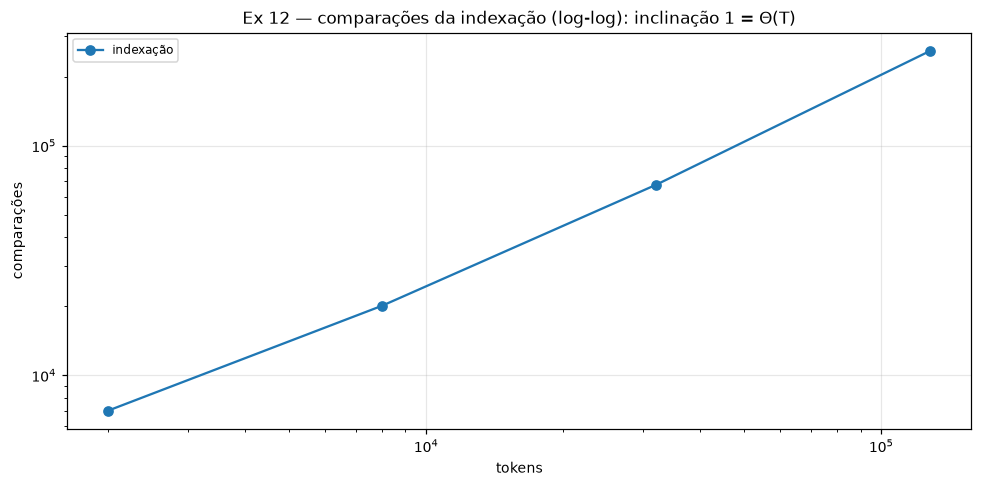

CUSTO DE INDEXAÇÃO


,documentos,tokens,vocabulario,ocorrencias,comparisons,comparacoes/tokens,altura_bst,altura_ideal,balanceamento,tempo_us_por_token
0,50,2000,317,1413,7021,3.5105,19,9,2.1111,8.4129
1,200,8000,396,5539,20105,2.5131,19,9,2.1111,7.7052
2,800,32000,400,22142,67639,2.1137,19,9,2.1111,9.3948
3,3200,128000,400,88484,258932,2.0229,19,9,2.1111,9.4192


In [13]:
indexacao = pd.DataFrame(bench_indexing())
grafico_loglog(indexacao.assign(curva="indexação"), "tokens", "comparisons", "curva",
               "Ex 12 — comparações da indexação (log-log): inclinação 1 = Θ(T)",
               "ex12_indexacao.png", "comparações")
mostrar(indexacao, ["documentos", "tokens", "vocabulario", "ocorrencias", "comparisons",
                    "comparacoes/tokens", "altura_bst", "altura_ideal", "balanceamento",
                    "tempo_us_por_token"],
        "CUSTO DE INDEXAÇÃO")

In [14]:
grande = SearchEngine(generate_corpus(400, vocabulary_size=600, words_per_document=60))
relatorio = performance_report(
    grande, ["algoritmo AND ordenacao", "(arvore OR lista) AND NOT pilha", "busca"],
    missing_term="algoritmoo")

print("ÍNDICE")
for chave, valor in relatorio["indice"].items():
    print(f"  {chave:<24} {valor:,.2f}" if isinstance(valor, float) else f"  {chave:<24} {valor:,}")
print("\nBST DE TERMOS")
for chave in ("termos", "altura", "altura_ideal", "balanceamento", "niveis", "largura_maxima"):
    print(f"  {chave:<24} {relatorio['bst_de_termos'][chave]}")
print("\nPOR ETAPA DA CONSULTA")
print(pd.DataFrame(relatorio["consultas"])[
    ["consulta", "termos", "resultados", "parsing_comparacoes", "avaliacao_comparacoes",
     "ranqueamento_comparacoes", "tempo_parsing_s", "tempo_avaliacao_s",
     "tempo_ranqueamento_s"]].to_string(index=False))
print("\nSUGESTÃO")
for chave, valor in relatorio["sugestao"].items():
    print(f"  {chave:<24} {valor}")

ÍNDICE
  documentos               400
  tokens                   24,000
  vocabulario              600
  tokens_por_documento     60.00

BST DE TERMOS
  termos                   600
  altura                   20
  altura_ideal             10
  balanceamento            2.0
  niveis                   20
  largura_maxima           76

POR ETAPA DA CONSULTA
                       consulta  termos  resultados  parsing_comparacoes  avaliacao_comparacoes  ranqueamento_comparacoes  tempo_parsing_s  tempo_avaliacao_s  tempo_ranqueamento_s
        algoritmo AND ordenacao       2         395                    0                    407                      4211           0.0000             0.0004                0.0188
(arvore OR lista) AND NOT pilha       3         128                    0                   1688                      1280           0.0000             0.0004                0.0090
                          busca       1         374                    0                      1         

### Custo assintótico de cada etapa

Com `D` documentos, `T` tokens, `V` termos distintos, `h` a altura da BST, `q`
termos na consulta, `P` o tamanho das listas envolvidas e `R` os resultados:

| Etapa | Caso médio | Pior caso |
|---|---|---|
| tokenizar + indexar | Θ(T + V·h) | Θ(T + V²) |
| `postings(termo)` | O(1 + α) | O(V) |
| listar termos em ordem | Θ(V) | Θ(V) |
| parsing (shunting-yard) | Θ(q) | Θ(q) |
| avaliar a consulta | Θ(P) | Θ(P + D) com `NOT` |
| ranquear | Θ(R·Σdf + R log R) | Θ(R²) |
| sugerir termo | Θ(V + C·L²) com poda | Θ(V·L²) sem |
| relatório BFS | Θ(V) | Θ(V) |

**Onde está o gargalo.** A tabela do relatório mostra que, em consultas comuns, o
**ranqueamento** domina: ele percorre a lista de ocorrências de cada termo para
cada documento do resultado. O parsing é irrelevante (Θ(q), com `q` na casa das
unidades) e a avaliação é barata porque as listas já estão ordenadas.

**O pior caso da indexação tem nome.** `Θ(T + V²)` acontece se os documentos
chegarem com vocabulário já ordenado: a BST de termos degenera e cada termo novo
custa O(V) em vez de O(log V). É o mesmo cenário do exercício 3 aparecendo pela
terceira vez — no ex 6 ele aconteceu sozinho, aqui ele é hipotético porque os
termos chegam em ordem de texto, que é quase aleatória. A coluna `balanceamento`
da tabela de indexação confirma: fica em torno de 2,1× a altura ideal.

### As duas otimizações, consolidadas

| # | Otimização | De | Para | Ganho medido | Exata? |
|---|---|---|---|---|---|
| 1 | Interseção por varredura de listas ordenadas | Θ(m·n) | Θ(m+n) | 26× a 1.642× (cresce com n) | sim, testado |
| 2 | Poda por diferença de comprimento na sugestão | Θ(V·L²) | Θ(V + C·L²) | ~2,1× em chamadas e tempo | sim, testado |

A otimização 1 é de **classe** e por isso o ganho cresce sem limite com o tamanho
das listas. A 2 é de **constante** — ela não muda o `V` do laço, só torna a maior
parte das iterações O(1) —, e por isso o ganho estabiliza em torno de 2×. As duas
foram medidas com as versões antiga e nova lado a lado, e há teste provando que
cada uma produz exatamente o mesmo resultado que substitui.